In [5]:

import h5py
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

import yaml
from TraceSimulator import TraceSimulator, NoiseGenerator

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml')
ts = TraceSimulator(config)
ng = NoiseGenerator(config)



In [16]:
trace,(x, y, z) = ts.generate(800, type_recoil='NR') # generate a 20 keV ER from a random position in the volume

In [17]:
trace.shape

(1, 56, 80000)

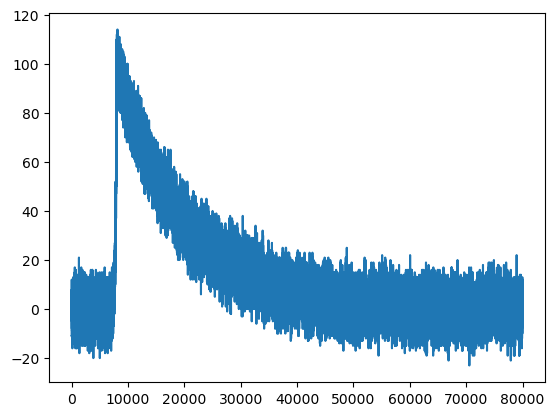

In [20]:
plt.plot(trace[0][7])

In [21]:
np.save("uv_noisy_80000.npy", trace[0][7])

In [6]:
noise=ng.generate_noise(10000)

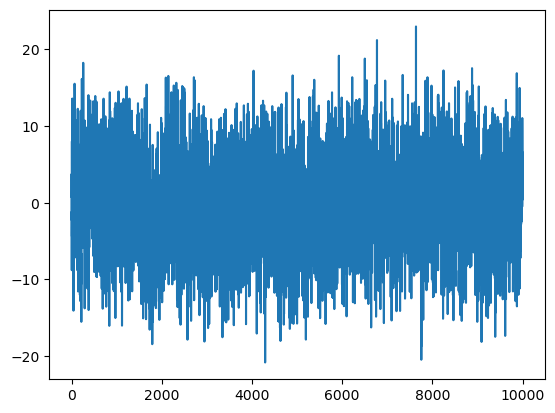

In [7]:
plt.plot(noise)

In [11]:
sample_dir = Path.cwd().parent / "samples"
input_path = sample_dir / "uv_noisy_32768.npy"
output_path = sample_dir / "uv_shift_32768.npy"

# Keep the inserted noise prefix within the tutorial fit_with_shift scan range.
noise_prefix_len = 12000

trace_32768 = np.load(input_path).astype(np.float64)
pure_noise = ng.generate_noise(noise_prefix_len)

shifted_trace = np.concatenate([pure_noise, trace_32768])[: trace_32768.size]
np.save(output_path, shifted_trace)

print("Input trace :", input_path)
print("Output trace:", output_path)
print("Input shape :", trace_32768.shape)
print("Output shape:", shifted_trace.shape)
print("Noise prefix:", noise_prefix_len)


Input trace : /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_noisy_32768.npy
Output trace: /home/dwong/DELight_mtr/PCA_dev/reusable/OF_tutorial/samples/uv_shift_32768.npy
Input shape : (32768,)
Output shape: (32768,)
Noise prefix: 12000


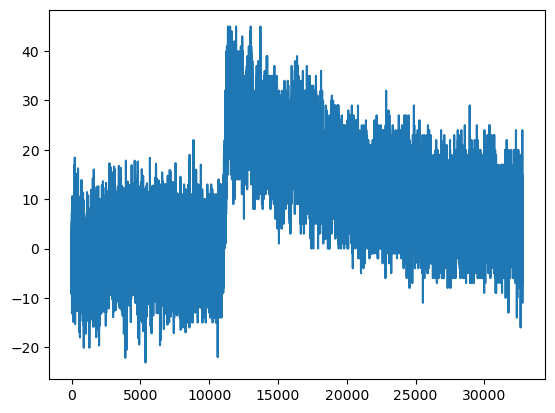

In [10]:
plt.plot(shifted_trace)